# Key stages of a data science pipeline

**Rahnema College ML Bootcamp 1405** · Week 2 · Peyman Naseri

---

The previous notebook was about **tools**: NumPy, pandas, matplotlib. This one
is about **order** — in what sequence, and for what purpose, you use those
tools on a real project.

Why cover this now rather than in the final week? Because the single most
common misconception in this field is that a data scientist's job is "building
models". Modelling is stage five of nine, and usually the shortest and cheapest
of them. If you carry a map of the whole route from today, the next seven weeks
of the bootcamp fall into place.

> The framework below follows this article:
> [What's Data Science Pipeline?](https://www.geeksforgeeks.org/data-science/whats-data-science-pipeline/)
> — not because it is the only correct breakdown, but because it is short and
> it matches what you actually see in practice.

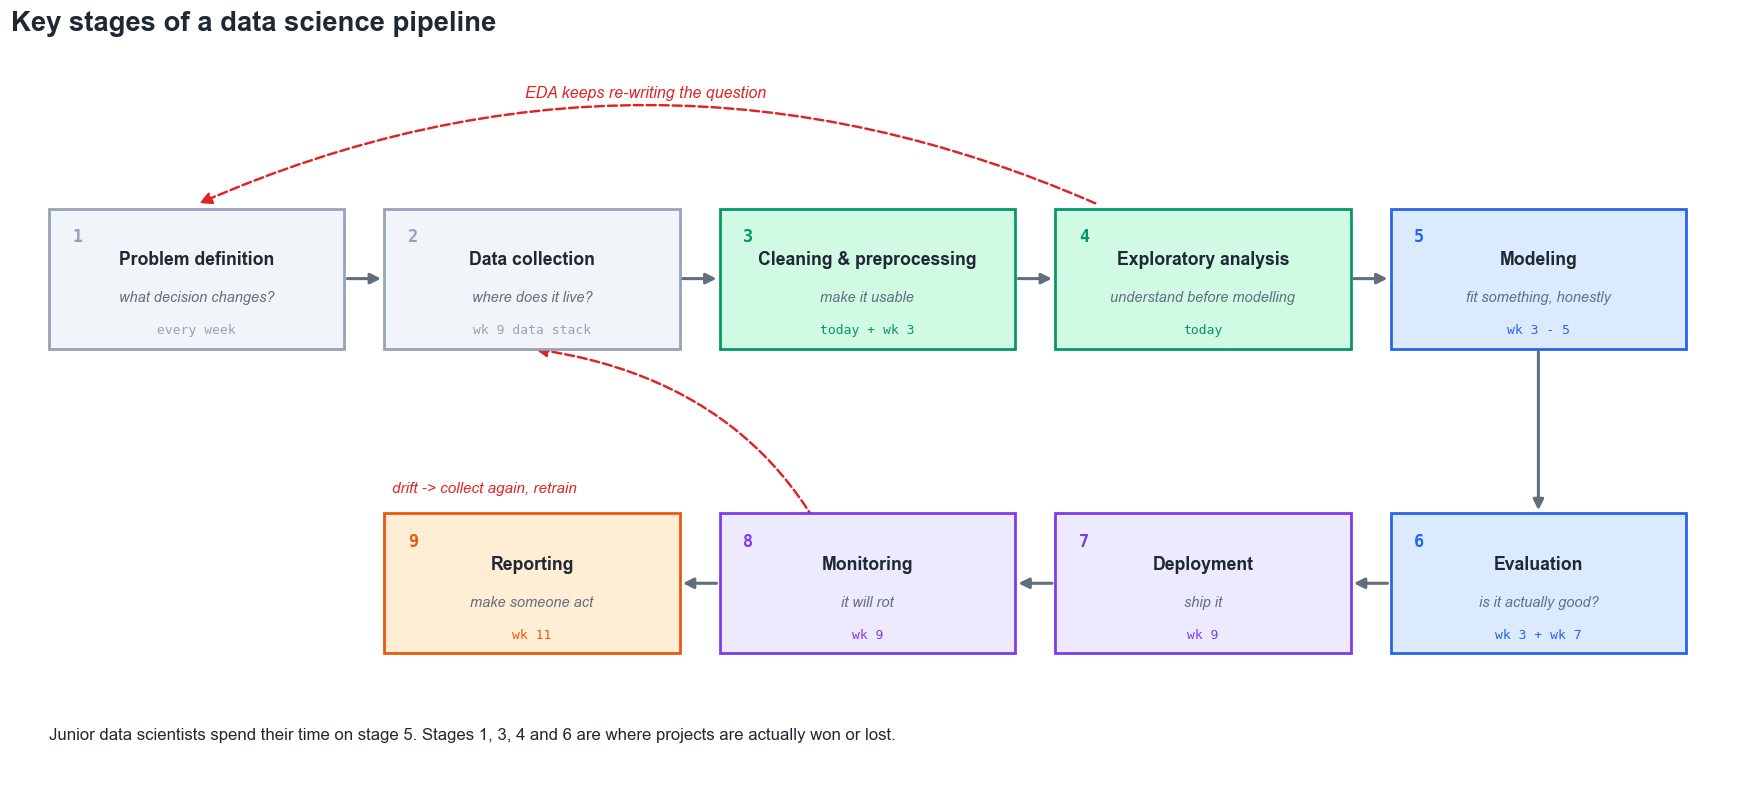

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

plt.rcParams.update({"figure.figsize": (7.5, 4.2), "figure.dpi": 110,
                     "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False})
sns.set_theme(style="whitegrid", palette="deep", rc=plt.rcParams)

# Same seed as notebook 01. We need a generator here for the bootstrap in the
# EDA section further down.
rng = np.random.default_rng(1405)

from bootcamp import pipeline_diagram

pipeline_diagram();

The two red arrows are the most important thing in that figure. These nine
stages are not a linear checklist; they are a loop. Every time you look at the
data, your question changes a little.

---

## 1. Problem definition

Before a single line of code. The right question is not "what should we
predict?" — it is:

> **What decision changes because of this work, and what if it doesn't?**

If you cannot answer that, no model you build will matter. Three questions to
ask whoever owns the problem:

- What is the downstream decision, and who makes it?
- How is that decision made today, without a model? (That is your baseline,
  and it is usually better than you expect.)
- What does "success" mean, as a single number? And how much does that number
  have to move before the work was worth doing?

**Common failure:** a project with 94% accuracy whose output nobody uses,
because the decision maker needed a number at 8am and the model answers at 11.

---

## 2. Data collection

From the company database, an API, a sensor, a public dataset, web scraping.
In practice, 90% of the time it is SQL against a warehouse.

Three things you have to settle here, because you cannot settle them later:

- **Granularity.** What exactly is one row of your data? One order? One line
  item within an order? One user on one day? Get this wrong and every number
  you compute afterwards answers a different question than the one you asked.
- **Recorded time versus event time.** A column that was updated "yesterday"
  did not exist yesterday. That distinction is the main source of data leakage
  — there is a whole workshop on it next week.
- **Privacy.** Are you allowed to use this column?

**In the bootcamp:** week 9, Mobin Nik-khesal's "modern data stack" session.

---

## 3. Cleaning and preprocessing

Missing values, format normalisation, encoding categoricals, scaling, feature
engineering.

Usually takes the largest share of the project and earns you the least credit.
The first-look ritual in block 4 of the previous notebook is the start of this
stage.

**The golden rule:** any preprocessing decision that *learns* something from
the data — a mean for imputation, a standard deviation for scaling, the set of
one-hot categories — must learn it **from the training data only**. That is why
next week I insist you put all of it inside a `Pipeline`. `Pipeline` is not a
matter of coding style; it is the only systematic way to stop yourself
cheating by accident.

**In the bootcamp:** today (the tools) plus week 3 (the correct method).

---

## 4. Exploratory data analysis — EDA

The stage we open up in detail below.

---

## 5. Modelling

Split into train / validation / test, choose an algorithm, tune
hyperparameters.

The only thing I want to say about it today is the order:

> **Split first, then do everything else.**

And always start with a stupid baseline: `DummyRegressor`, "the same value as
yesterday", "the group median". Until you have compared your model against
that, you do not know whether you have achieved anything. Three weeks of work
on a model that is worse than the median is a real and common event.

**In the bootcamp:** week 3 (classical), week 4 (neural nets), week 5
(transformers).

---

## 6. Model evaluation

Accuracy, precision/recall, RMSE, AUC — and spotting overfitting.

Two points worth making:

- **Choose the metric before you see the results.** Otherwise you will
  unconsciously pick the metric your model happens to be good at.
- **The metric has to connect to the decision from stage 1.** On imbalanced
  data, accuracy lies: a model that always says "not fraud" gets 99.9%
  accuracy on 99.9% legitimate transactions and is worth exactly nothing.

**In the bootcamp:** week 3 (metrics) and week 7 (LLM evaluation, which is a
harder problem).

---

## 7. Deployment

An API, a batch job, or a stream.

The sentence worth memorising: **a notebook is not a product.** If the output
of your work is only an `.ipynb`, you delivered an analysis, not a system. And
in the bootcamp's final project, milestone 2 is exactly this: a public URL that
works.

**In the bootcamp:** week 9 (Docker, model serving).

---

## 8. Monitoring and maintenance

Your model **will** degrade. Not because the code has a bug, but because the
world moves: user behaviour, product mix, a new competitor. It is called drift
and it is unavoidable.

The minimum you must do: log the distribution of your inputs and the
distribution of your predictions. If today's input distribution does not look
like the one you trained on, your model is guessing.

**In the bootcamp:** week 7 (monitoring and tracing with Langfuse), week 9.

---

## 9. Reporting

And after all of that, somebody has to act.

Your result is only as usable as your *worst* slide. Three rules:

- Lead with the **decision**, not the method. "I recommend X" in the first
  sentence.
- Put every number next to its reference number. "12 minutes" means nothing;
  "12 minutes, against a target of 15 and 18 last month" means something.
- State the uncertainty. "Between 10 and 14 minutes with 95% confidence" makes
  you credible, not weak.

**In the bootcamp:** week 10 (presentation coaching) and week 11 (final
presentations).

---

# Stage 4 in detail: EDA

## Why we open this one up

Three reasons:

1. **It has the highest return on investment.** One hour of proper EDA
   typically produces more value than a day of hyperparameter tuning.
2. **You already have the tools, as of today.** EDA is nothing more than
   pandas, a plot, and the right question.
3. **It is the only stage that changes all the other stages.** EDA tells you to
   build a feature, change your metric, or rewrite the question entirely.

## What EDA is **not**

- Running `df.describe()` and moving on.
- Producing forty plots and looking at none of them.
- Using a correlation matrix as a substitute for thinking. Correlation measures
  a *linear* relationship and misses U-shaped ones completely.

## What EDA is: four questions, in this order

| # | Question | Tools |
|---|---|---|
| 1 | What does each column look like on its own? | `describe`, histogram, `value_counts` |
| 2 | What do the variables do to each other? | scatter, group means, boxplot |
| 3 | What segments does the data split into, and do they differ? | `groupby`, `pivot_table` |
| 4 | What here is broken or suspicious? | edge values, NaNs, outlier rows |

Below we run exactly those four questions on yesterday's dataset, driven by a
real business question.

---

## EDA in practice

**The business question:** we have four dark stores. There is budget to improve
one of them. Which one, and what should we fix?

No model. Just looking.

In [2]:
# Same cleaning as notebook 01, block 4 -- see there for what each step fixes.
orders = (
    pd.read_csv(DATA / "qcommerce_orders.csv", parse_dates=["order_time"])
      .drop_duplicates()
      .assign(courier_type=lambda d: d["courier_type"].str.strip().str.lower())
)
orders = orders.loc[orders["delivery_minutes"] > 0].reset_index(drop=True)
orders = orders.merge(pd.read_csv(DATA / "qcommerce_stores.csv"),
                      on="store", how="left", validate="m:1")

print("shape:", orders.shape)
orders.head(3)

shape: (239, 13)


,order_id,order_time,store,courier_type,basket_size,basket_value_toman,picking_minutes,delivery_minutes,rating,city,region,opened_year,area_m2
0,100144,2025-08-02 10:46:00,Vakilabad,bicycle,5,735000,6.5,18.6,3.0,Mashhad,east,2023,275
1,100004,2025-08-02 12:14:00,Saadatabad,motorcycle,7,971000,9.2,12.5,5.0,Tehran,north,2022,310
2,100114,2025-08-02 13:02:00,Gohardasht,motorcycle,3,304000,5.8,14.5,5.0,Karaj,west,2024,190


### Question 1 — each column on its own

Start with the target variable: delivery time. The question is not "what is its
mean" — it is **"what does normal look like, and how long is the tail?"**

n           : 239
mean        : 17.4 min
median      : 16.2 min
p90         : 23.5 min
p99         : 45.0 min
max         : 53.1 min
skew        : 2.44


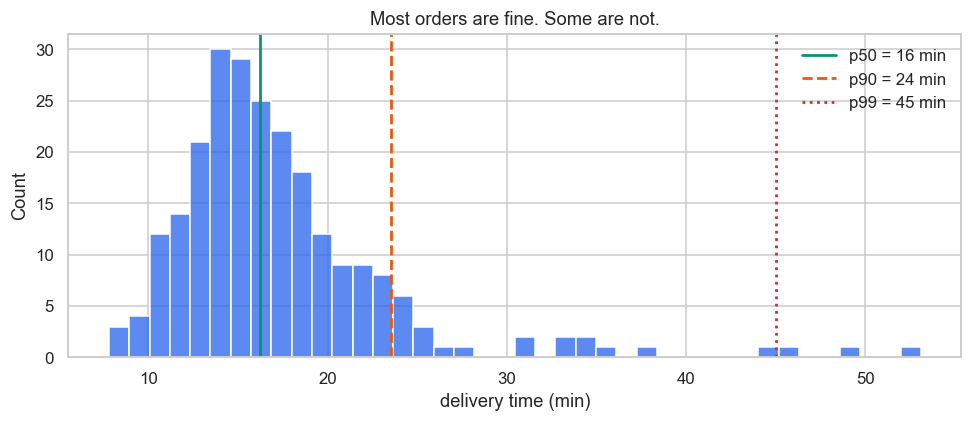

In [3]:
d = orders["delivery_minutes"]

# Percentiles, not just mean and std. On skewed data the mean is a poor
# summary and the std is nearly uninterpretable.
print(f"n           : {len(d)}")
print(f"mean        : {d.mean():.1f} min")
print(f"median      : {d.median():.1f} min")
print(f"p90         : {d.quantile(0.90):.1f} min")
print(f"p99         : {d.quantile(0.99):.1f} min")
print(f"max         : {d.max():.1f} min")
print(f"skew        : {d.skew():.2f}")     # 0 = symmetric, >1 = strongly right-skewed

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(d, bins=40, ax=ax, color="#2563eb")
# Drawing the percentiles on the histogram makes the tail impossible to ignore.
for q, colour, style in [(0.5, "#059669", "-"), (0.9, "#ea580c", "--"),
                         (0.99, "#dc2626", ":")]:
    ax.axvline(d.quantile(q), color=colour, ls=style, lw=1.8,
               label=f"p{int(q * 100)} = {d.quantile(q):.0f} min")
ax.set(xlabel="delivery time (min)", title="Most orders are fine. Some are not.")
ax.legend(frameon=False)
fig.tight_layout()

The mean is above the median and the skew is about 2.4 — the distribution has a
**tail**. That is the first real finding, and it affects the decision directly:

the median is about 16 minutes, p90 about 23, but p99 is about 45 minutes. One
customer in a hundred waits nearly three times the median. If your KPI is
"average delivery time", that customer disappears from your number entirely.

**On skewed data, report percentiles, not the mean.** That is a *metric*
decision (stage 6) that came out of EDA, not out of a planning meeting. It also
raises the next question, which we come back to: is that tail a genuinely rare
event, or a data error?

### Question 2 — relationships

Before asking "which store is worse", we have to establish that delivery time
**matters at all**. Otherwise we are optimising a number nobody cares about.

correlation (pearson): -0.658


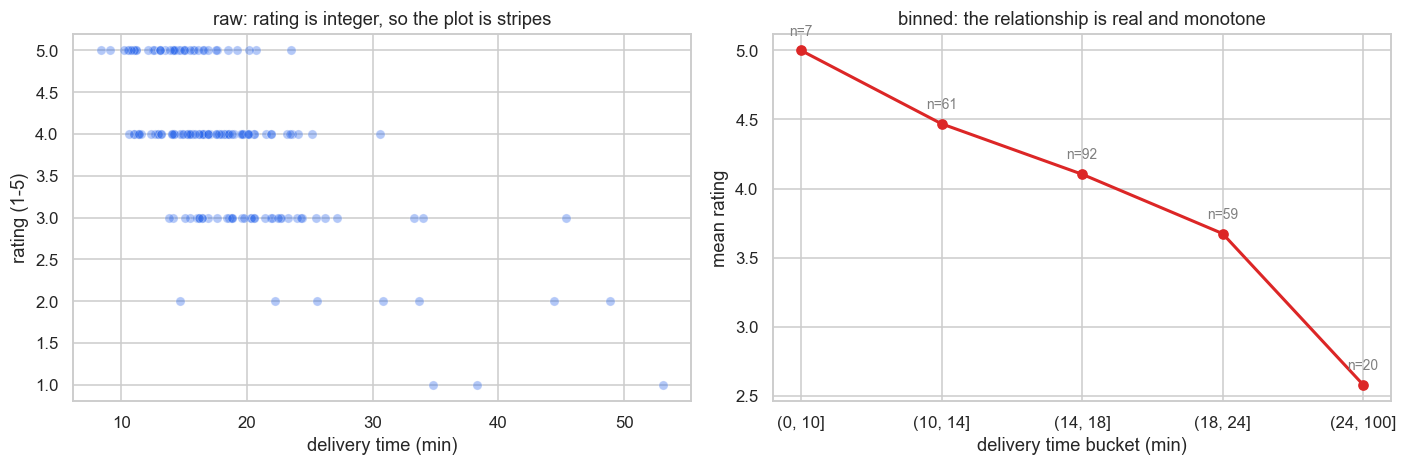

In [4]:
fig, (ax_rel, ax_bin) = plt.subplots(1, 2, figsize=(13, 4.4))

# Raw scatter first -- always look at the points before trusting a summary.
sns.scatterplot(orders, x="delivery_minutes", y="rating", alpha=0.35,
                ax=ax_rel, color="#2563eb")
ax_rel.set(xlabel="delivery time (min)", ylabel="rating (1-5)",
           title="raw: rating is integer, so the plot is stripes")

# Binning makes the trend visible without hiding the sample size. pd.cut with
# explicit edges instead of qcut, so the buckets are round numbers we can
# talk about; observed=True stops empty categories appearing in the result.
bins = pd.cut(orders["delivery_minutes"], bins=[0, 10, 14, 18, 24, 100])
binned = orders.groupby(bins, observed=True).agg(
    mean_rating=("rating", "mean"),
    n=("rating", "size"),
)
ax_bin.plot(range(len(binned)), binned["mean_rating"], "o-", color="#dc2626", lw=2)
ax_bin.set(xticks=range(len(binned)),
           xticklabels=[str(i) for i in binned.index],
           xlabel="delivery time bucket (min)", ylabel="mean rating",
           title="binned: the relationship is real and monotone")
# Annotating n on each point is the difference between a finding and a guess.
for i, (_, row) in enumerate(binned.iterrows()):
    ax_bin.annotate(f"n={int(row['n'])}", (i, row["mean_rating"]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, color="grey")
fig.tight_layout()

print(f"correlation (pearson): {orders['delivery_minutes'].corr(orders['rating']):.3f}")

There is a relationship, it goes one way, and it is not small: from the 10–14
minute bucket to the 18–24 one, roughly every 5 minutes of delay costs about
half a star — and the slope steepens in the tail (the bucket above 24 minutes
drops below 3). Now we are entitled to take delivery time seriously.

Two technical notes about that same figure:

- **Raw points first, summary second.** The left plot is ugly but it tells you
  `rating` is an integer. If you had only seen the right plot, you would not
  know what the mean is being taken over.
- **Write `n` on every bucket.** Look at the first bucket: its mean rating is
  exactly 5.00 — a suspiciously round number — and it is computed from about 7
  observations. That point has no story, it has noise. Most misleading analyses
  start right there.

### Question 3 — segmentation: which store?

In [5]:
by_store = orders.groupby("store").agg(
    # "size" counts rows including NaNs; "count" would skip them.
    orders=("order_id", "size"),
    median_delivery=("delivery_minutes", "median"),
    # No named aggregator for an arbitrary quantile, hence the lambda.
    p90_delivery=("delivery_minutes", lambda s: s.quantile(0.90)),
    # mean() drops NaNs silently, so this is the mean among those who rated...
    mean_rating=("rating", "mean"),
    # ...and this says what fraction that was. Always report the pair.
    rated_share=("rating", lambda s: s.notna().mean()),
).sort_values("median_delivery", ascending=False).round(2)

by_store

,orders,median_delivery,p90_delivery,mean_rating,rated_share
store,,,,,
Gohardasht,35,20.00,25.96,3.62,0.83
Punak,54,16.45,22.35,3.72,0.74
Vakilabad,62,16.40,21.32,3.95,0.68
Saadatabad,88,14.05,23.56,4.08,0.56


By median the answer is clear: **Gohardasht**. About 6 minutes slower than
Saadatabad, with the lowest mean rating too. So far everything agrees.

But look at the `p90_delivery` column. **Saadatabad, which has the best median,
has the second worst p90.** That means one of two things: either Saadatabad has
two different problems (good baseline, bad tail), or that p90 is not a
trustworthy number at all.

This is exactly where bad analyses stop and good ones take one more step.

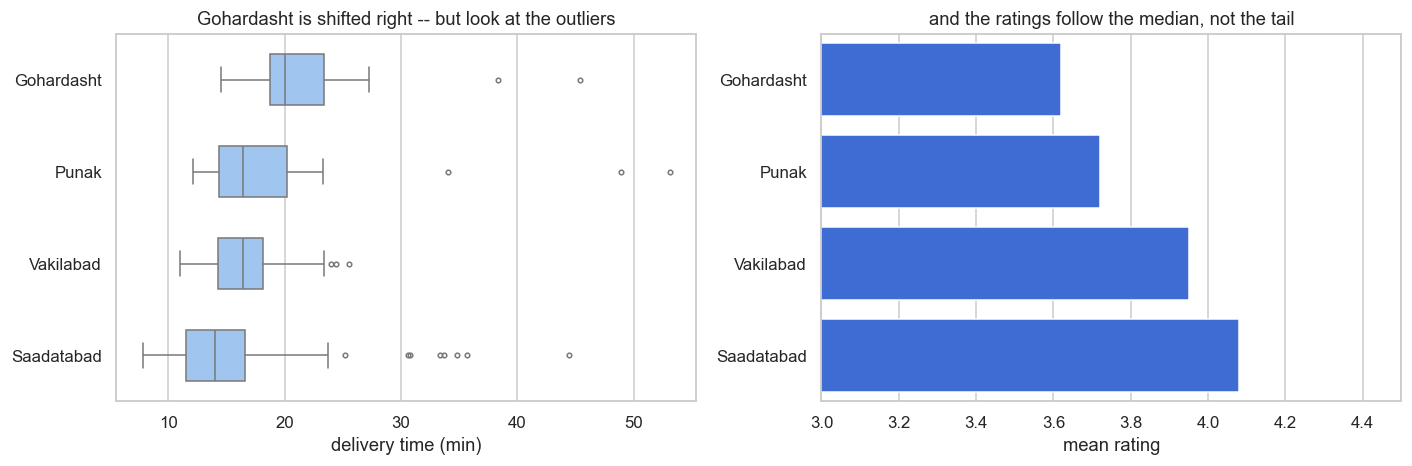

In [6]:
fig, (ax_dist, ax_rat) = plt.subplots(1, 2, figsize=(13, 4.4))

order = by_store.index.tolist()   # slowest first, so both panels agree

# A bar chart of medians hides the shape. Show the whole distribution.
sns.boxplot(orders, y="store", x="delivery_minutes", order=order, ax=ax_dist,
            width=0.55, color="#93c5fd", fliersize=3)
ax_dist.set(xlabel="delivery time (min)", ylabel="",
            title="Gohardasht is shifted right -- but look at the outliers")

sns.barplot(by_store.reset_index(), y="store", x="mean_rating", order=order,
            ax=ax_rat, color="#2563eb")
# xlim starts at 3, not 0: all the variation is in the top third of the scale
# and a 0-based axis would flatten it into four identical bars.
ax_rat.set(xlabel="mean rating", ylabel="", xlim=(3, 4.5),
           title="and the ratings follow the median, not the tail")
fig.tight_layout()

### Are those differences real? — the bootstrap

Each store has between 35 and 88 orders. A p90 on 35 observations is
effectively computed from the top three or four points. How much can we trust
that number?

You need no statistical formula here. We use the same tool we built yesterday
in block 3: **simulation**. The bootstrap idea, in one sentence:

> If the only thing you have from the population is this sample, then resample
> *from that sample itself* with replacement, compute the statistic each time,
> and see how much it moves.

That spread is the uncertainty of your statistic.

In [7]:
def bootstrap_ci(values, q, n_boot=5_000, level=0.95):
    """Resample `values` with replacement and return a CI for its q-quantile."""
    # One (n_boot, n) array of resamples rather than a loop -- block 0 again.
    draws = rng.choice(values, size=(n_boot, len(values)), replace=True)
    stats = np.quantile(draws, q, axis=1)
    # The percentile bootstrap: the middle 95% of the resampled statistics.
    lo, hi = np.quantile(stats, [(1 - level) / 2, 1 - (1 - level) / 2])
    return lo, hi


ci_rows = []
for store, group in orders.groupby("store"):
    v = group["delivery_minutes"].to_numpy()
    med_lo, med_hi = bootstrap_ci(v, 0.50)
    p90_lo, p90_hi = bootstrap_ci(v, 0.90)
    ci_rows.append({"store": store, "n": len(v),
                    "median": np.median(v), "med_lo": med_lo, "med_hi": med_hi,
                    "p90": np.quantile(v, 0.90), "p90_lo": p90_lo, "p90_hi": p90_hi})

ci = (pd.DataFrame(ci_rows)
        .sort_values("median", ascending=False)
        .reset_index(drop=True))
ci.round(1)

,store,n,median,med_lo,med_hi,p90,p90_lo,p90_hi
0,Gohardasht,35,20.0,18.8,22.3,26.0,23.6,38.3
1,Punak,54,16.4,15.5,18.0,22.4,20.5,34.0
2,Vakilabad,62,16.4,15.3,17.2,21.3,18.6,23.8
3,Saadatabad,88,14.0,13.1,14.8,23.6,17.9,33.3


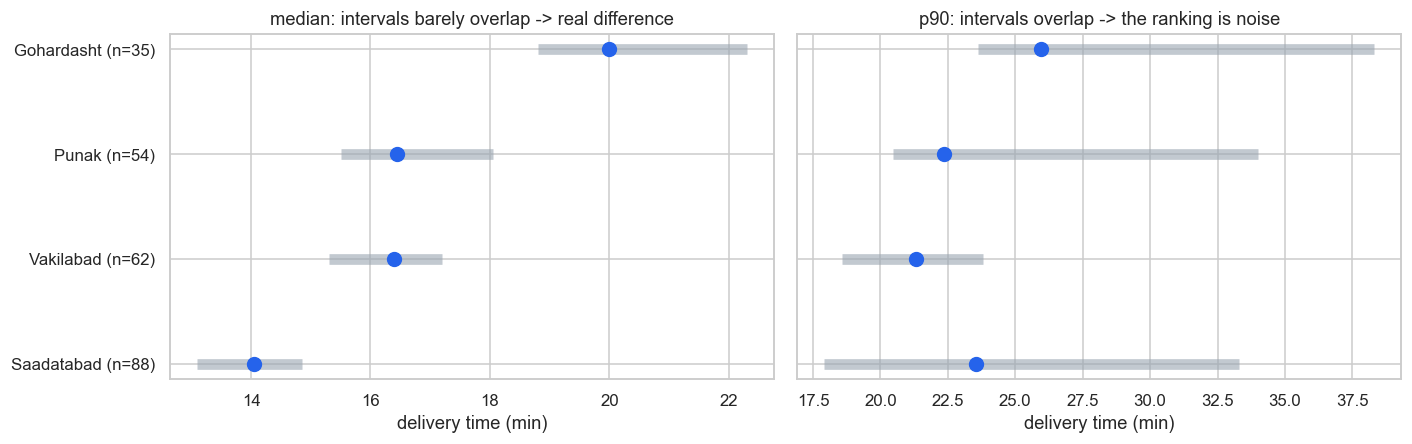

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

ys = np.arange(len(ci))
labels = [f"{s} (n={n})" for s, n in zip(ci["store"], ci["n"])]

# hlines draws the interval, the marker draws the point estimate. Reading two
# rows whose intervals do not overlap is the whole purpose of this figure.
for ax, point, lo, hi in [(axes[0], "median", "med_lo", "med_hi"),
                          (axes[1], "p90", "p90_lo", "p90_hi")]:
    ax.hlines(ys, ci[lo], ci[hi], color="#9aa5b1", lw=7, alpha=0.6)
    ax.plot(ci[point], ys, "o", color="#2563eb", ms=9)
    ax.set(yticks=ys, yticklabels=labels, xlabel="delivery time (min)")

axes[0].set_title("median: intervals barely overlap -> real difference")
axes[1].set_title("p90: intervals overlap -> the ranking is noise")
axes[0].invert_yaxis()   # slowest store on top, same order as the boxplot
fig.tight_layout()

We have an answer, and it comes in two parts:

- **The difference in medians is real.** Gohardasht's interval is roughly
  [19, 22] and Saadatabad's is roughly [13, 15]. They do not overlap. That
  finding is reportable.
- **The p90 ranking is not real.** The p90 intervals are so wide and so
  overlapping that "Saadatabad has the second worst tail" is an unsupported
  sentence. That number came from three or four outlying orders.

Without the bootstrap we would probably have spent budget fixing a problem that
does not exist. **A summary table does not tell you which of its columns you
can trust; you have to ask that yourself.**

Practical rule: any statistic that looks at the tail of a distribution (p90,
p95, max, rare-event rates) is wildly unstable on a small sample. High
percentiles need more data than medians do — the same $1/\sqrt{n}$ from
yesterday, again.

### One layer deeper: why Gohardasht?

We have the "which". If you report only that, the first question back will be:
"why? and what can we actually do?"

Candidate hypotheses: the store's inherent distance, courier mix, basket size,
peak hour. We test the simplest one that the data can confirm or kill.

In [9]:
# Hypothesis: Gohardasht is slow because it uses more (slower) bicycles.
# normalize="index" turns the counts into a share per row, which is what
# "mix" means -- raw counts would just reflect store size.
mix = pd.crosstab(orders["store"], orders["courier_type"], normalize="index")
print("courier mix per store (share of orders):")
print(mix.round(3), "\n")

print("raw cell counts -- check these before trusting the medians below:")
print(pd.crosstab(orders["store"], orders["courier_type"]), "\n")

split = orders.pivot_table(index="store", columns="courier_type",
                           values="delivery_minutes", aggfunc="median")
print("median delivery, split by courier type:")
print(split.round(1), "\n")
print("bicycle penalty per store (min):")
print((split["bicycle"] - split["motorcycle"]).round(1))

courier mix per store (share of orders):
courier_type  bicycle  motorcycle
store                            
Gohardasht      0.171       0.829
Punak           0.315       0.685
Saadatabad      0.227       0.773
Vakilabad       0.274       0.726 

raw cell counts -- check these before trusting the medians below:
courier_type  bicycle  motorcycle
store                            
Gohardasht          6          29
Punak              17          37
Saadatabad         20          68
Vakilabad          17          45 

median delivery, split by courier type:
courier_type  bicycle  motorcycle
store                            
Gohardasht       20.8        20.0
Punak            18.5        15.7
Saadatabad       15.9        13.2
Vakilabad        18.6        15.0 

bicycle penalty per store (min):
store
Gohardasht    0.8
Punak         2.8
Saadatabad    2.8
Vakilabad     3.6
dtype: float64


The hypothesis is **dead**, and in a stronger way than we expected:

Gohardasht has the **fewest** bicycles (about 17%, against 31% at Punak) and is
still the slowest. So not only does courier mix fail to explain it — Gohardasht
is the worst *despite* having the most favourable mix. If its mix looked like
Punak's, it would be worse still.

The bicycle penalty does exist independently, at roughly 3 minutes — in three
of the stores. **Do not believe** Gohardasht's number (under 1 minute): that
cell has only 6 orders. The "write down `n`" lesson, again.

So the honest conclusion: Gohardasht's slowness is **baseline**. Its starting
level is higher for both courier types. That is consistent with a
distance/coverage explanation, but confirming it needs data we **do not have**:
the actual distance of each order.

And that is itself one of the main outputs of EDA: **a specific data request,
not a guess.**

### Question 4 — what here is suspicious?

The most important and least practised part of EDA. There is one specific trap
in this dataset that we have ignored so far: `rating` is about a third missing.
Until now we called `mean()` and pandas quietly dropped the NaNs.

The right question is not "what should we do with the NaNs?" It is: **"are they
missing at random?"**

In [10]:
orders["was_rated"] = orders["rating"].notna()

print("missing share of rating:", f"{1 - orders['was_rated'].mean():.1%}\n")

# The test for non-random missingness: group by whether the value is missing,
# and compare the OTHER columns across those groups. If they differ, the
# missingness carries information.
check = orders.groupby("was_rated").agg(
    n=("order_id", "size"),
    mean_delivery=("delivery_minutes", "mean"),
    median_delivery=("delivery_minutes", "median"),
).round(2)
print(check, "\n")

gap = (check.loc[True, "mean_delivery"] - check.loc[False, "mean_delivery"])
print(f"rated orders were on average {gap:.1f} min slower than unrated ones.")

missing share of rating: 33.1%

             n  mean_delivery  median_delivery
was_rated                                     
False       79          15.11             14.4
True       160          18.49             16.9 

rated orders were on average 3.4 min slower than unrated ones.


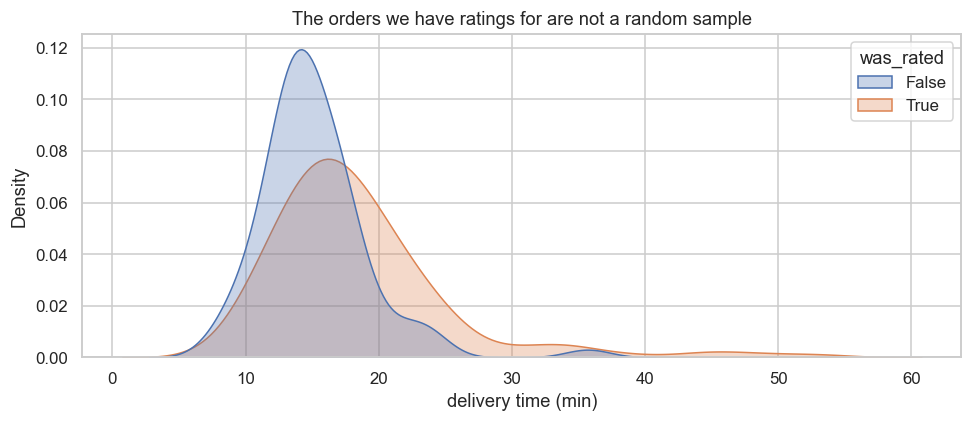

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
# common_norm=False so each group's density integrates to 1 separately --
# otherwise the bigger group dominates and you cannot compare the shapes.
sns.kdeplot(orders, x="delivery_minutes", hue="was_rated", fill=True,
            alpha=0.3, ax=ax, common_norm=False)
ax.set(xlabel="delivery time (min)",
       title="The orders we have ratings for are not a random sample")
fig.tight_layout()

Found it. Orders that have a rating are systematically **slower**. The reason
is entirely sensible: a satisfied customer does not leave feedback, an annoyed
one does.

So the `mean_rating` we reported in the table above is **biased, and more
pessimistic than reality**. Report it as "customer satisfaction" and you have
handed someone a number that is wrong — and nobody will notice.

The technical term is data that is "not missing at random". Three ways to
handle it:

| Approach | When |
|---|---|
| report it with the qualifier stated explicitly ("mean rating *of rated orders*") | always, as the minimum |
| model the act of rating as its own target | when whether-they-rated is itself a signal |
| inverse-probability weighting on the chance of rating | when you genuinely need an unbiased number |

What you must **not** do: `fillna(orders["rating"].mean())`. That takes the
bias, injects it into the whole dataset, and then makes it invisible.

⚠️ And if this column ever becomes a model feature, you have full-blown leakage
right here — because "did they rate or not" is only known after delivery. Next
week, after lunch, on exactly this subject.

### A look at time, before we close the file

Any dataset with a time column should be looked at along the time axis once.
The reason is simple: a sudden drop or jump is usually a pipeline bug, not a
fact about the business.

            orders  median
order_time                
False          125    15.0
True           114    17.5

 

orders per hour (watch the sample size before reading the medians):
order_time
10     2
11     8
12    24
13    35
14    12
15     2
16     2
17    14
18    26
19    44
20    44
21    15
22     8
23     3


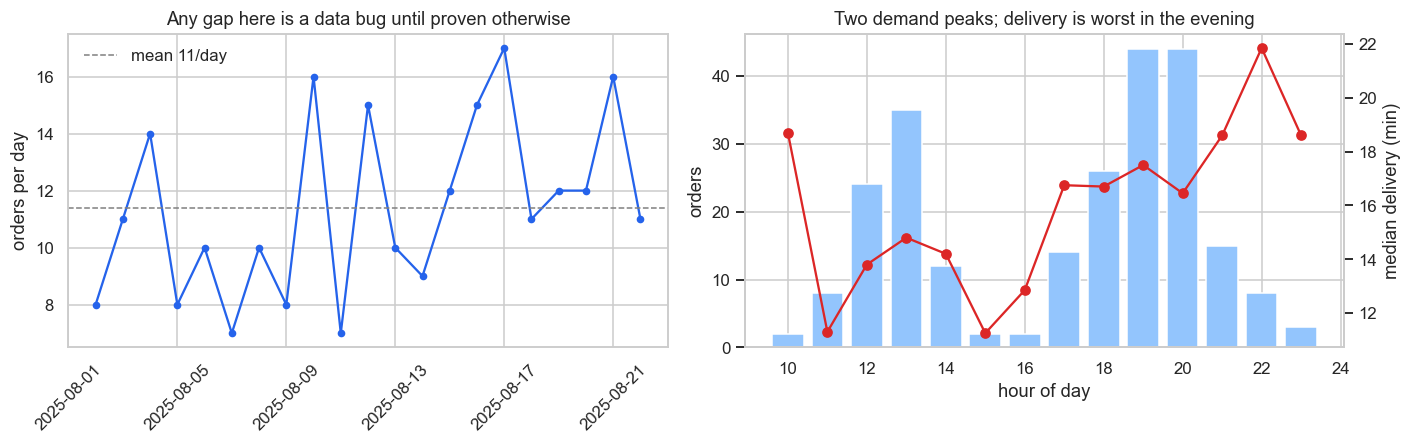

In [12]:
fig, (ax_day, ax_hour) = plt.subplots(1, 2, figsize=(13, 4.2))

daily = orders.set_index("order_time").resample("D").size()
ax_day.plot(daily.index, daily.values, marker="o", ms=4, color="#2563eb")
ax_day.axhline(daily.mean(), ls="--", lw=1, color="grey",
               label=f"mean {daily.mean():.0f}/day")
ax_day.set(ylabel="orders per day",
           title="Any gap here is a data bug until proven otherwise")
ax_day.tick_params(axis="x", rotation=45)
ax_day.legend(frameon=False)

hourly = orders.groupby(orders["order_time"].dt.hour).agg(
    orders=("order_id", "size"),
    median_delivery=("delivery_minutes", "median"),
)
ax_hour.bar(hourly.index, hourly["orders"], color="#93c5fd", label="orders")
ax_hour.set(xlabel="hour of day", ylabel="orders")
# twinx shares the x-axis and adds a second y-axis on the right. Use sparingly:
# it lets you compare two different units, and it also lets you mislead.
twin = ax_hour.twinx()
twin.plot(hourly.index, hourly["median_delivery"], "o-", color="#dc2626",
          label="median delivery")
twin.set_ylabel("median delivery (min)")
twin.grid(False)     # two grids on one plot is unreadable
ax_hour.set_title("Two demand peaks; delivery is worst in the evening")
fig.tight_layout()

evening = orders["order_time"].dt.hour >= 19
print(orders.groupby(evening)["delivery_minutes"]
            .agg(orders="size", median="median").round(1), "\n")
print("orders per hour (watch the sample size before reading the medians):")
print(hourly["orders"].to_string())

Demand has two peaks (lunch and evening) and the evening one is larger.
Delivery time rises from 19:00 onwards: median after 19:00 is about 17.5
minutes against 15.0 for the rest of the day.

One necessary caution, and it is the same lesson again: the worst hourly median
belongs to 22:00, where demand is **low** — which is tempting to read as "so it
is not volume pressure, it is evening capacity". But look at the order-count
row: that hour has only a handful of orders. That single number cannot carry
the weight of a diagnosis on its own.

What we **can** say with confidence is at the level of the evening block, not
hour by hour.

Either way the operational finding is: **the evening block, not the whole
day.** Which is roughly half the cost of "more couriers at all hours".

Once again: this decision did not come from a model. It came from a `groupby`
and two axes.

---

## Our EDA output, in six lines

What you hand to the next stage matters more than how many plots you drew:

1. **The metric changed:** report median and percentiles, not the mean, because
   the distribution is skewed. And report high percentiles with a confidence
   interval, because at this data volume they are unstable.
2. **An answer to the business question:** Gohardasht. Its slowness is
   baseline, not a consequence of courier mix — and that difference was
   confirmed with a bootstrap.
3. **A claim killed:** "Saadatabad has a bad tail" is not defensible with the
   data we have. Killing a claim is also an output.
4. **One concrete action:** capacity in the evening block (19:00 onwards), not
   across the whole day.
5. **A warning:** the mean rating is biased and pessimistic; it must not be
   reported as-is.
6. **A data request:** the actual distance of each order, to confirm the
   geography hypothesis.

We trained no model.

---

## The EDA checklist — stick this above your monitor

**Before any plot**
- [ ] What exactly is one row of this data? (granularity)
- [ ] `shape`, `dtypes`, `isna().mean()`, `duplicated().sum()`
- [ ] Every categorical column: `value_counts(dropna=False)` — how many
      distinct values? different spellings?

**Univariate**
- [ ] For every numeric column: median, p90, p99, `min`/`max` — not just the mean
- [ ] Skewed? → report percentiles, and plot on a log scale
- [ ] Impossible values? (negatives, suspicious zeros, 999, future dates)

**Bivariate**
- [ ] Raw points first, summary second
- [ ] Write `n` on every group — a small group is noise
- [ ] Zero correlation ≠ no relationship (look at the plot)
- [ ] Any difference you intend to report: get a bootstrap interval for it

**Segmentation**
- [ ] `groupby` on the natural keys; do the groups differ?
- [ ] Is the difference explained by a different mix, or is it a real group effect?

**Suspicious things**
- [ ] Are the missing values random? (`groupby(isna)` and compare)
- [ ] Are the outliers data errors, or important reality?
- [ ] For every column: **was this available at prediction time?** ← the leakage guard

**Hand-off**
- [ ] One decision, one action, one warning, one data request

---

# And now, a real one

Everything above ran on synthetic data so that it would stay small and
readable. In the session I walk through the same nine stages inside a real
analysis from my own work — same structure, none of the tidiness.

That notebook is not in this repository: it reads internal data and is shown
live rather than shared. What you should take from it is the habit rather than
the numbers.

The question to ask like a critic about any analysis, including your own:
**was every number you see available at the moment of the decision?**
